# Prediccion salarial con Deep Learning

Modelos:
- `SimpleRNN`
- `LSTM`
- `GRU`
- `CNN + LSTM`


In [2]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import openpyxl

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, SimpleRNN, LSTM, GRU, Conv1D, MaxPooling1D, Flatten, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

warnings.filterwarnings('ignore')
sns.set(style='whitegrid')
pd.set_option('display.max_columns', None)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
print('TensorFlow:', tf.__version__)


TensorFlow: 2.21.0


## 1) Carga de datos

Si no pasas ruta manual, intenta detectar un `.xlsx` o `.csv` en el directorio actual.


In [3]:
DATA_PATH = 'tech_jobs_salaries.xlsx'

if DATA_PATH.lower().endswith('.xlsx'):
    df = pd.read_excel(DATA_PATH)
else:
    df = pd.read_csv(DATA_PATH)

df.head()


,job_title,company_size,employment_type,experience_level,years_experience,education_level,country,salary_local_currency,currency,remote_type,primary_skill,secondary_skill,work_hours_per_week,job_satisfaction_score,company_rating,age,gender
0,DevOps Engineer,SME,Full-time,Entry,3,Self-taught,India,1087489,INR,Onsite,SQL,Java,35,2.7,3.3,22,Female
1,Mobile App Developer,SME,Full-time,Lead,14,Bachelor,Japan,25198412,USD,Onsite,Docker,TensorFlow,57,2.8,3.9,51,Male
2,Cloud Engineer,Startup,Freelance,Senior,14,Self-taught,India,2579715,INR,Onsite,Kubernetes,C++,52,3.2,4.2,44,Female
3,Cybersecurity Analyst,Startup,Full-time,Entry,3,Diploma,India,949111,INR,Hybrid,NoSQL,Docker,40,3.4,3.3,38,Male
4,Backend Developer,SME,Contract,Lead,10,Self-taught,Japan,25195363,USD,Onsite,Linux,TensorFlow,56,2.8,4.5,54,Male


In [5]:
display(df.info())
display(df.isnull().sum().sort_values(ascending=False).head(20))


<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 17 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   job_title               200000 non-null  str    
 1   company_size            200000 non-null  str    
 2   employment_type         200000 non-null  str    
 3   experience_level        200000 non-null  str    
 4   years_experience        200000 non-null  int64  
 5   education_level         200000 non-null  str    
 6   country                 200000 non-null  str    
 7   salary_local_currency   200000 non-null  int64  
 8   currency                200000 non-null  str    
 9   remote_type             200000 non-null  str    
 10  primary_skill           200000 non-null  str    
 11  secondary_skill         200000 non-null  str    
 12  work_hours_per_week     200000 non-null  int64  
 13  job_satisfaction_score  200000 non-null  float64
 14  company_rating          200000 

None

job_title                 0
company_size              0
employment_type           0
experience_level          0
years_experience          0
education_level           0
country                   0
salary_local_currency     0
currency                  0
remote_type               0
primary_skill             0
secondary_skill           0
work_hours_per_week       0
job_satisfaction_score    0
company_rating            0
age                       0
gender                    0
dtype: int64

## 2) Limpieza y target

Se normaliza salario a USD y se aplica `log1p` para estabilizar varianza.


In [6]:
required_cols = ['salary_local_currency', 'currency']
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f'Faltan columnas requeridas: {missing}')

# Tasas aproximadas.
currency_to_usd = {
    'USD': 1.0,
    'INR': 0.011,
    'EUR': 1.08,
    'GBP': 1.27,
    'CAD': 0.73,
    'AUD': 0.66,
    'MXN': 0.058,
    'COP': 0.00026,
}

df['currency_rate'] = df['currency'].map(currency_to_usd)
if df['currency_rate'].isna().any():
    # Fallback conservador para monedas no mapeadas
    df['currency_rate'] = df['currency_rate'].fillna(1.0)

df['salary_usd'] = df['salary_local_currency'] * df['currency_rate']

# Capping IQR para reducir impacto de extremos
q1 = df['salary_usd'].quantile(0.25)
q3 = df['salary_usd'].quantile(0.75)
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr

df['salary_usd_capped'] = df['salary_usd'].clip(lower, upper)
df['salary_log'] = np.log1p(df['salary_usd_capped'])

print('Bounds IQR:', lower, upper)
print('Salary_log describe:')
display(df['salary_log'].describe())


Bounds IQR: -83647.25 336346.75
Salary_log describe:


count    200000.000000
mean         11.572367
std           0.803348
min           8.034362
25%          11.209812
50%          11.651613
75%          12.094303
max          12.725901
Name: salary_log, dtype: float64

## 3) Ingenier?a de variables

Features adicionales creadas seg?n estructura t?pica de este dataset de salarios tech.


In [7]:
def safe_col(col, default=np.nan):
    return df[col] if col in df.columns else pd.Series(default, index=df.index)

# Mapas ordinales
exp_map = {
    'Entry': 0, 'Junior': 1, 'Mid': 2, 'Senior': 3, 'Lead': 4,
    'EN': 0, 'MI': 2, 'SE': 3, 'EX': 4
}
edu_map = {
    'High School': 0, 'Bachelor': 1, 'Master': 2, 'PhD': 3,
    'Secondary': 0
}
remote_map = {
    'Onsite': 0, 'Hybrid': 1, 'Remote': 2,
    'On-site': 0
}
size_map = {
    'S': 0, 'M': 1, 'L': 2,
    'Small': 0, 'Medium': 1, 'Large': 2
}

exp = safe_col('experience_level').astype(str)
edu = safe_col('education_level').astype(str)
remote = safe_col('remote_type').astype(str)
size = safe_col('company_size').astype(str)
country = safe_col('country').astype(str)
job_title = safe_col('job_title').astype(str)
primary_skill = safe_col('primary_skill').astype(str)
secondary_skill = safe_col('secondary_skill').astype(str)

# Nuevos features
work_df = df.copy()
work_df['experience_level_num'] = exp.map(exp_map).fillna(2)
work_df['education_level_num'] = edu.map(edu_map).fillna(1)
work_df['remote_score'] = remote.map(remote_map).fillna(1)
work_df['company_size_num'] = size.map(size_map).fillna(1)

work_df['is_us'] = (country.str.upper() == 'UNITED STATES').astype(int)
work_df['same_skill_flag'] = (primary_skill.str.lower() == secondary_skill.str.lower()).astype(int)
work_df['job_title_len'] = job_title.str.len().fillna(job_title.str.len().median())

work_df['exp_x_edu'] = work_df['experience_level_num'] * work_df['education_level_num']
work_df['exp_x_remote'] = work_df['experience_level_num'] * work_df['remote_score']

high_demand_roles = ['data scientist', 'ml engineer', 'ai engineer', 'data engineer', 'software engineer']
work_df['high_demand_role'] = job_title.str.lower().apply(lambda x: int(any(r in x for r in high_demand_roles)))

work_df[['experience_level_num','education_level_num','remote_score','company_size_num','is_us','same_skill_flag','job_title_len','exp_x_edu','exp_x_remote','high_demand_role']].head()


,experience_level_num,education_level_num,remote_score,company_size_num,is_us,same_skill_flag,job_title_len,exp_x_edu,exp_x_remote,high_demand_role
0,0,1.0,0,1.0,0,0,15,0.0,0,0
1,4,1.0,0,1.0,0,0,20,4.0,0,0
2,3,1.0,0,1.0,0,0,14,3.0,0,0
3,0,1.0,1,1.0,0,0,21,0.0,0,0
4,4,1.0,0,1.0,0,0,17,4.0,0,0


In [8]:
# Columnas categ?ricas candidatas
candidate_cat_cols = [
    'job_title', 'company_size', 'employment_type', 'experience_level', 'education_level',
    'country', 'remote_type', 'primary_skill', 'secondary_skill', 'gender'
]
cat_cols = [c for c in candidate_cat_cols if c in work_df.columns]

# Evitar leakage: no incluir target ni columnas de salario original
drop_cols = [
    'salary_local_currency', 'salary_usd', 'salary_usd_capped', 'salary_log', 'currency', 'currency_rate'
]
drop_cols = [c for c in drop_cols if c in work_df.columns]

encoded = pd.get_dummies(work_df, columns=cat_cols, drop_first=True)
X = encoded.drop(columns=drop_cols, errors='ignore')
y = encoded['salary_log'].astype(np.float32)

# Asegurar num?rico
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True)).fillna(0)
X = X.astype(np.float32)

print('X shape:', X.shape)
print('y shape:', y.shape)


X shape: (200000, 86)
y shape: (200000,)


## 4) Split, escalado y reshape para redes secuenciales

Para usar RNN/LSTM/GRU en tabular, se representa cada fila como una secuencia de longitud = n?mero de features y 1 canal.


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=SEED
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc = scaler.transform(X_val)
X_test_sc = scaler.transform(X_test)

# (samples, timesteps, channels)
X_train_seq = np.expand_dims(X_train_sc, axis=-1)
X_val_seq = np.expand_dims(X_val_sc, axis=-1)
X_test_seq = np.expand_dims(X_test_sc, axis=-1)

print('Train seq:', X_train_seq.shape)
print('Val seq:', X_val_seq.shape)
print('Test seq:', X_test_seq.shape)


Train seq: (128000, 86, 1)
Val seq: (32000, 86, 1)
Test seq: (40000, 86, 1)


In [10]:
input_shape = (X_train_seq.shape[1], 1)


def build_simplernn(input_shape):
    model = Sequential([
        SimpleRNN(64, input_shape=input_shape, activation='tanh'),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model


def build_lstm(input_shape):
    model = Sequential([
        LSTM(64, input_shape=input_shape),
        Dropout(0.25),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model


def build_gru(input_shape):
    model = Sequential([
        GRU(64, input_shape=input_shape),
        Dropout(0.25),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model


def build_cnn_lstm(input_shape):
    model = Sequential([
        Conv1D(filters=64, kernel_size=3, activation='relu', padding='same', input_shape=input_shape),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        LSTM(32),
        Dropout(0.25),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model


## 5) Entrenamiento y evaluaci?n comparativa


In [11]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, verbose=0)
]

model_builders = {
    'SimpleRNN': build_simplernn,
    'LSTM': build_lstm,
    'GRU': build_gru,
    'CNN_LSTM': build_cnn_lstm,
}

histories = {}
predictions = {}
results = []

for name, builder in model_builders.items():
    print(f'\nEntrenando {name}...')
    model = builder(input_shape)

    history = model.fit(
        X_train_seq, y_train,
        validation_data=(X_val_seq, y_val),
        epochs=50,
        batch_size=256,
        callbacks=callbacks,
        verbose=0
    )

    y_pred = model.predict(X_test_seq, verbose=0).ravel()

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # M?tricas en escala original USD
    y_test_usd = np.expm1(y_test)
    y_pred_usd = np.expm1(y_pred)
    rmse_usd = np.sqrt(mean_squared_error(y_test_usd, y_pred_usd))
    mae_usd = mean_absolute_error(y_test_usd, y_pred_usd)

    results.append({
        'Modelo': name,
        'RMSE_log': rmse,
        'MAE_log': mae,
        'R2_log': r2,
        'RMSE_USD': rmse_usd,
        'MAE_USD': mae_usd
    })

    histories[name] = history.history
    predictions[name] = y_pred

results_df = pd.DataFrame(results).sort_values('RMSE_log')
display(results_df)



Entrenando SimpleRNN...

Entrenando LSTM...

Entrenando GRU...

Entrenando CNN_LSTM...


,Modelo,RMSE_log,MAE_log,R2_log,RMSE_USD,MAE_USD
1,LSTM,0.805065,0.605343,-0.007341,97165.184876,69304.820312
2,GRU,0.818034,0.626866,-0.040056,100879.430292,71335.875000
0,SimpleRNN,0.830020,0.643735,-0.070759,103061.538122,72812.507812
3,CNN_LSTM,0.837456,0.652814,-0.090030,104005.390630,73542.546875


Mejor modelo por RMSE_log: LSTM


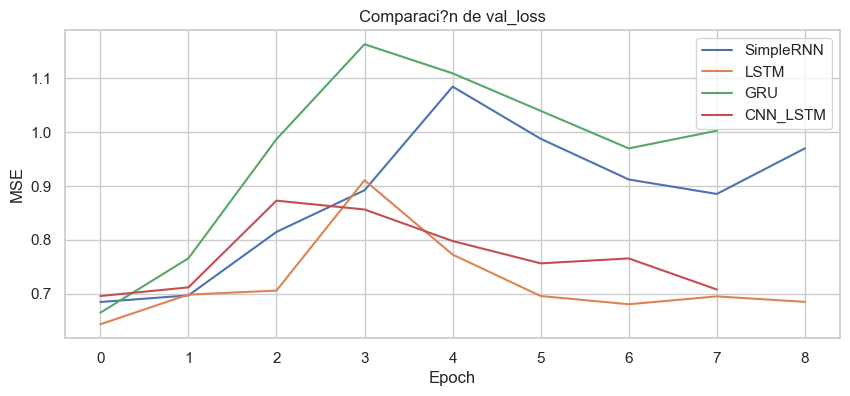

In [12]:
best_model_name = results_df.iloc[0]['Modelo']
print('Mejor modelo por RMSE_log:', best_model_name)

plt.figure(figsize=(10, 4))
for name, hist in histories.items():
    plt.plot(hist['val_loss'], label=name)
plt.title('Comparaci?n de val_loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.show()


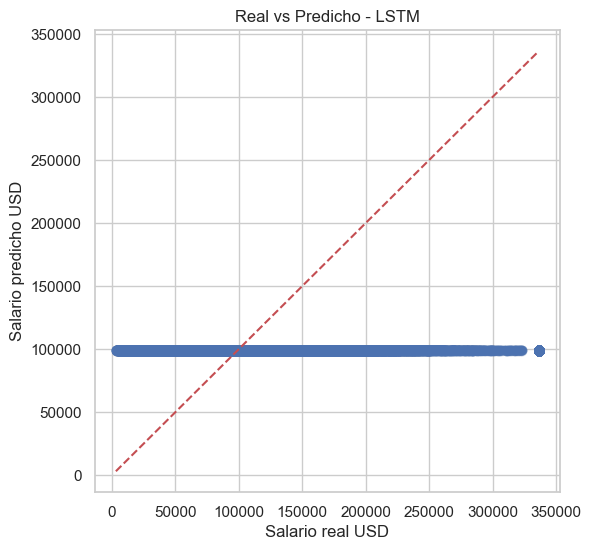

In [13]:
# Gr?fico real vs predicho para mejor modelo
best_pred = predictions[best_model_name]

y_true_usd = np.expm1(y_test)
y_pred_usd = np.expm1(best_pred)

plt.figure(figsize=(6, 6))
plt.scatter(y_true_usd, y_pred_usd, alpha=0.2)
min_v = min(y_true_usd.min(), y_pred_usd.min())
max_v = max(y_true_usd.max(), y_pred_usd.max())
plt.plot([min_v, max_v], [min_v, max_v], 'r--')
plt.xlabel('Salario real USD')
plt.ylabel('Salario predicho USD')
plt.title(f'Real vs Predicho - {best_model_name}')
plt.show()


## 6) Conclusiones recomendadas

- Si `R2_log` mejora y `MAE_USD` baja, el modelo captura mejor patrones no lineales.
- En tabular puro, `GRU/LSTM` pueden no superar modelos tipo ?rboles, pero esta versi?n ya est? correctamente orientada a redes secuenciales.
- Para subir precisi?n: agregar features temporales (a?o/mes), seniority granular en a?os, embeddings para `job_title` y skills, y tuning sistem?tico.
